# Benchmark Answer Generator Comparison

This notebook demonstrates how to use the `run_benchmarks` API to evaluate and compare different `AnswerGenerator` implementations. It runs both the `fix_error` and `api_understanding` benchmark suites and visualizes the pass rate of each generator.


In [1]:
import asyncio
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import the necessary components from the benchmark framework
from benchmarks import benchmark_orchestrator
from benchmarks.answer_generators import (
    GroundTruthAnswerGenerator,
    TrivialAnswerGenerator,
)

# Set a nice style for the plots
sns.set_theme(style="whitegrid")

## 1. Configure and Run the Benchmarks

First, we define which benchmark suites and which answer generators we want to run. For this comparison, we'll run all available suites and compare the `GroundTruthAnswerGenerator` (which should always be perfect) against the `TrivialAnswerGenerator` (which provides a simple, often incorrect, answer).

In [14]:
async def run_comparison():
    """Sets up and runs the benchmark comparison."""
    print("Configuring benchmark run...")
    
    benchmark_suites = [
        "benchmarks/benchmark_definitions/fix_error_benchmarks.yaml",
        # "benchmarks/benchmark_definitions/api_understanding_benchmarks.yaml",
    ]
    
    answer_generators = [
        GroundTruthAnswerGenerator(), 
        TrivialAnswerGenerator()
    ]
    
    print("Executing benchmarks...")
    summary_df = (
        await benchmark_orchestrator.run_benchmarks(
            benchmark_suites, answer_generators
        )
    )
    
    return summary_df

In [15]:
raw_results_df = await run_comparison()

Configuring benchmark run...
Executing benchmarks...
--- Running benchmark suite: benchmarks/benchmark_definitions/fix_error_benchmarks.yaml ---
  - Using answer generator: GroundTruthAnswerGenerator
  - Using answer generator: TrivialAnswerGenerator


In [16]:
raw_results_df

,suite,benchmark_name,answer_generator,result,logs
0,fix_error_benchmarks.yaml,01: A minimal LlmAgent,GroundTruthAnswerGenerator,1,--- Pytest stdout ---\n[1m===================...
1,fix_error_benchmarks.yaml,02: An LlmAgent with a simple function tool,GroundTruthAnswerGenerator,1,--- Pytest stdout ---\n[1m===================...
2,fix_error_benchmarks.yaml,03: An LlmAgent that uses output_schema to enf...,GroundTruthAnswerGenerator,1,--- Pytest stdout ---\n[1m===================...
3,fix_error_benchmarks.yaml,04: A SequentialAgent orchestrating two simple...,GroundTruthAnswerGenerator,1,--- Pytest stdout ---\n[1m===================...
4,fix_error_benchmarks.yaml,05: A ParallelAgent running two agents concurr...,GroundTruthAnswerGenerator,1,--- Pytest stdout ---\n[1m===================...
5,fix_error_benchmarks.yaml,06: A LoopAgent that runs a sub-agent a fixed ...,GroundTruthAnswerGenerator,1,--- Pytest stdout ---\n[1m===================...
6,fix_error_benchmarks.yaml,07: A root agent delegating a task to a sub-agent,GroundTruthAnswerGenerator,0,--- Pytest stdout ---\n[1m===================...
7,fix_error_benchmarks.yaml,08: A simple custom agent with conditional logic,GroundTruthAnswerGenerator,0,--- Pytest stdout ---\n[1m===================...
8,fix_error_benchmarks.yaml,10: An agent that writes to and reads from ses...,GroundTruthAnswerGenerator,0,--- Pytest stdout ---\n[1m===================...
9,fix_error_benchmarks.yaml,11: A direct implementation test for InMemoryR...,GroundTruthAnswerGenerator,0,--- Pytest stdout ---\n[1m===================...


In [17]:
# Calculate summary from raw results
summary_df = (
  raw_results_df.groupby("answer_generator")["result"]
  .agg(["sum", "count"])
  .rename(columns={"sum": "passed", "count": "total"})
)
summary_df["pass_rate"] = summary_df["passed"] / summary_df["total"]


### Executing the Asynchronous Function

Because Jupyter Notebooks run on an active `asyncio` event loop, we cannot use `asyncio.run()`. Instead, we call our async function directly with `await`.

In [18]:
# 2. Display and Visualize the Results

print("--- Benchmark Summary ---")
print(summary_df)

# %% [markdown]
# ## 3. Analyze Detailed Pass/Fail Logs
# 
# In addition to the summary, the `run_benchmarks` function also returns a raw results DataFrame containing the outcome of every individual test case. We can use this to investigate specific failures or verify successes.

# %% 
def analyze_logs(results_df, generator_name, result_type='fail'):
    """Filters and displays benchmark results for a specific generator and result type."""
    
    # Convert result_type to the integer value used in the DataFrame (0 for fail, 1 for pass)
    result_value = 1 if result_type.lower() == 'pass' else 0
    
    print(f"--- Analyzing {result_type.upper()}S for {generator_name} ---\n")
    
    # Filter the DataFrame for the specified generator and result
    filtered_df = results_df[
        (results_df['answer_generator'] == generator_name) & 
        (results_df['result'] == result_value)
    ]
    
    if filtered_df.empty:
        print(f"No {result_type}s found for {generator_name}.")
        return
    
    # Display the details of each pass or fail
    for _, row in filtered_df.iterrows():
        print(f"Suite: {row['suite']}")
        print(f"Benchmark: {row['benchmark_name']}")
        print("-" * 20)
        
# --- Configuration ---
# Set the generator and result type you want to inspect
generator_to_analyze = 'GroundTruthAnswerGenerator' # Or 'TrivialAnswerGenerator'
result_type_to_see = 'fail' # Or 'pass'

analyze_logs(raw_results_df, generator_to_analyze, result_type_to_see)

--- Benchmark Summary ---
                            passed  total  pass_rate
answer_generator                                    
GroundTruthAnswerGenerator       7     19   0.368421
TrivialAnswerGenerator           7     19   0.368421
--- Analyzing FAILS for GroundTruthAnswerGenerator ---

Suite: fix_error_benchmarks.yaml
Benchmark: 07: A root agent delegating a task to a sub-agent
--------------------
Suite: fix_error_benchmarks.yaml
Benchmark: 08: A simple custom agent with conditional logic
--------------------
Suite: fix_error_benchmarks.yaml
Benchmark: 10: An agent that writes to and reads from session.state
--------------------
Suite: fix_error_benchmarks.yaml
Benchmark: 11: A direct implementation test for InMemoryRunner
--------------------
Suite: fix_error_benchmarks.yaml
Benchmark: 12: An App instance that includes a basic plugin
--------------------
Suite: fix_error_benchmarks.yaml
Benchmark: 13: An LlmAgent with a BuiltInCodeExecutor
--------------------
Suite: fix_error

## 4. Display and Visualize the Summary Results

Finally, we display the summary DataFrame and create the bar chart for a high-level comparison, as before.

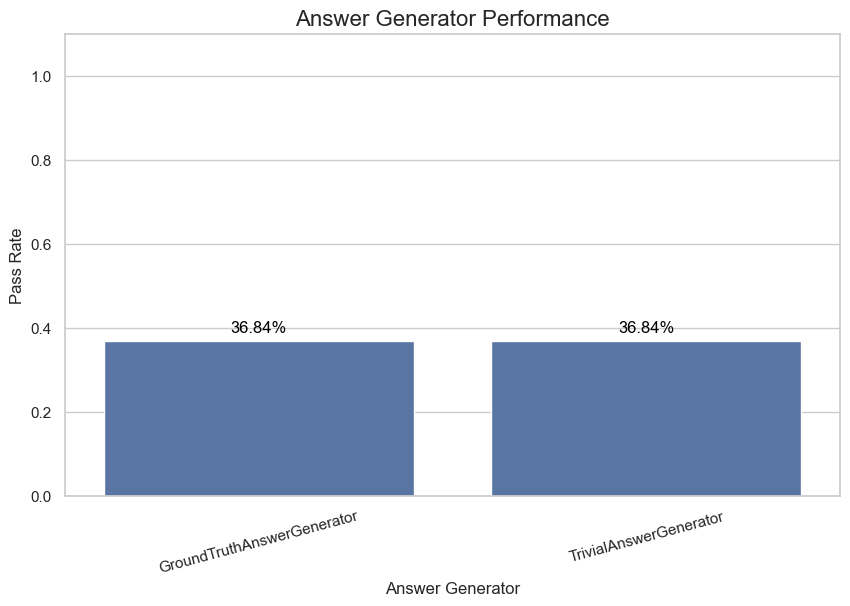

In [19]:
# Create the visualization
plt.figure(figsize=(10, 6))
sns.barplot(x=summary_df.index, y=summary_df['pass_rate'])

plt.title('Answer Generator Performance', fontsize=16)
plt.xlabel('Answer Generator', fontsize=12)
plt.ylabel('Pass Rate', fontsize=12)
plt.ylim(0, 1.1) # Set y-axis limit to be just above 1.0 for clarity
plt.xticks(rotation=15) # Rotate labels slightly for better readability

# Add the pass rate value on top of each bar
for index, row in summary_df.iterrows():
    plt.text(row.name, row.pass_rate + 0.02, f'{row.pass_rate:.2%}', color='black', ha="center")

plt.show()